In [2]:
import pandas as pd
data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

#### Checking the data

In [3]:
print(data.head())
print(data.shape)
data.info()
data.describe()

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


#### Checking for Duplicate Records and Target Distribution

In [4]:
print(data.duplicated().sum())
print(data["Attrition"].value_counts())
print(data["Attrition"].value_counts(normalize=True))

0
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64


#### Separating Features and Target Variable

In [5]:
features = data.drop("Attrition", axis=1)
X = features
y = data[["Attrition"]]
print(X.shape)
print(y.shape)

(1470, 34)
(1470, 1)


#### Splitting the Dataset into Training and Testing Sets

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

#### Encoding Features and Target

In [7]:
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
le_overtime = LabelEncoder()
X_train["Label_Gender"] = le_gender.fit_transform(X_train["Gender"])
X_test["Label_Gender"] = le_gender.transform(X_test["Gender"])
X_train["Label_OverTime"] = le_overtime.fit_transform(X_train["OverTime"])
X_test["Label_OverTime"] = le_overtime.transform(X_test["OverTime"])
#doing one hot encoding
X_train = pd.get_dummies(X_train, columns = ["Department","EducationField","JobRole","MaritalStatus","BusinessTravel"], dtype = int)
X_test = pd.get_dummies(X_test, columns = ["Department","EducationField","JobRole","MaritalStatus","BusinessTravel"], dtype = int)

#Encoding the target
le_attrition = LabelEncoder()
y_train["Label_Attrition"] = le_attrition.fit_transform(y_train["Attrition"])
y_test["Label_Attrition"] = le_attrition.transform(y_test["Attrition"])

# Convert target to 1D format required by scikit-learn models
y_train = y_train["Label_Attrition"]
y_test = y_test["Label_Attrition"]

#Deleting the previous columns where characters where there and unnecessary columns
X_train.drop(["Gender","OverTime", "EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], axis = 1, inplace = True)
X_test.drop(["Gender","OverTime", "EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"], axis = 1, inplace = True)


#### Feature Scaling Numerical Features

In [8]:
from sklearn.preprocessing import MinMaxScaler
for_scaling_X_train = X_train[['Age','DailyRate',
       'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction','HourlyRate',
       'JobInvolvement', 'JobLevel','JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction','StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']]
scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(for_scaling_X_train)
scaled_columns_X_train = pd.DataFrame(scaled_X_train, columns = for_scaling_X_train.columns, index = for_scaling_X_train.index)


#For X_test
for_scaling_X_test = X_test[['Age','DailyRate',
       'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction','HourlyRate',
       'JobInvolvement', 'JobLevel','JobSatisfaction',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction','StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']]

scaled_X_test = scaler.transform(for_scaling_X_test)
scaled_columns_X_test = pd.DataFrame(scaled_X_test, columns = for_scaling_X_test.columns, index = for_scaling_X_test.index)


#Replacing the original features with scaled ones
X_train[for_scaling_X_train.columns] = scaled_columns_X_train
X_test[for_scaling_X_test.columns] = scaled_columns_X_test

In [9]:
print(y_train.shape)
print(y_test.shape)
print(y_train.head())
print(y_test.head())

(1176,)
(294,)
1097    0
727     0
254     0
1175    0
1341    0
Name: Label_Attrition, dtype: int64
1041    0
184     0
1222    1
67      0
220     0
Name: Label_Attrition, dtype: int64


## Model Training - Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
model = LogisticRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")
c_matrix = confusion_matrix(y_test, prediction)
print("The confusion matrix is")
print(c_matrix)

Accuracy: 88.77551020408163%
Precision: 65.0%
Recall: 33.33333333333333%
F1: 44.06779661016949%
The confusion matrix is
[[248   7]
 [ 26  13]]


## Model Training - K-Nearest Neighbors (KNN)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix
model = KNeighborsClassifier(9)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")
c_matrix = confusion_matrix(y_test, prediction)
print("The confusion matrix is")
print(c_matrix)

Accuracy: 88.77551020408163%
Precision: 87.5%
Recall: 17.94871794871795%
F1: 29.78723404255319%
The confusion matrix is
[[254   1]
 [ 32   7]]


## Model Training - Decision Tree

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, confusion_matrix
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")
c_matrix = confusion_matrix(y_test, prediction)
print("The confusion matrix is")
print(c_matrix)

Accuracy: 77.55102040816327%
Precision: 20.0%
Recall: 23.076923076923077%
F1: 21.428571428571427%
The confusion matrix is
[[219  36]
 [ 30   9]]


## Model Training - Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
prediction = model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)
print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")
c_matrix = confusion_matrix(y_test, prediction)
print("The confusion matrix is")
print(c_matrix)

Accuracy: 87.41496598639455%
Precision: 66.66666666666666%
Recall: 10.256410256410255%
F1: 17.77777777777778%
The confusion matrix is
[[253   2]
 [ 35   4]]


#### Model Performance Comparison

In [14]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "KNN (k=9)", "Decision Tree", "Random Forest"],
    "Accuracy": [88.78, 87.76, 88.78, 77.55, 87.41],
    "Precision": [65.00, 61.54, 87.50, 20.00, 66.67],
    "Recall": [33.33, 20.51, 17.95, 23.08, 10.26],
    "F1": [44.07, 30.77, 29.79, 21.43, 17.78]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,88.78,65.00,33.33,44.07
1,KNN,87.76,61.54,20.51,30.77
2,KNN (k=9),88.78,87.50,17.95,29.79
3,Decision Tree,77.55,20.00,23.08,21.43
4,Random Forest,87.41,66.67,10.26,17.78


## Hyperparameter Tuning - Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
model = LogisticRegression()
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}
grid = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    cv = 5
)
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_estimator_)

{'C': 1}
LogisticRegression(C=1)


#### Evaluating the Tuned model

In [16]:
best_model = grid.best_estimator_ #LogisticRegression(C=1)
prediction = best_model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")

c_matrix = confusion_matrix(y_test, prediction)
print("The confusion matrix is")
print(c_matrix)
"""Hyperparameter tuning with the tested C values did not improve Logistic Regression performance. GridSearchCV selected C=1, which is also the model's default value."""

Accuracy: 88.77551020408163%
Precision: 65.0%
Recall: 33.33333333333333%
F1: 44.06779661016949%
The confusion matrix is
[[248   7]
 [ 26  13]]


"Hyperparameter tuning with the tested C values did not improve Logistic Regression performance. GridSearchCV selected C=1, which is also the model's default value."

#### Class Imbalance, balancing the class

In [17]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight="balanced")
model.fit(X_train,y_train)
prediction = model.predict(X_test)

#### Evaluation after class balancing

In [18]:
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")

c_matrix = confusion_matrix(y_test, prediction)
print("The confusion matrix is")
print(c_matrix)

Accuracy: 74.82993197278913%
Precision: 28.39506172839506%
Recall: 58.97435897435898%
F1: 38.333333333333336%
The confusion matrix is
[[197  58]
 [ 16  23]]


#### Tuning the unbalanced class

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

model = LogisticRegression()
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced'] #Added another hyperparameter
    #None->Treating the class equally
    #balanced -> giving more importance to minority
}

grid= GridSearchCV(
    estimator=model,
    param_grid = param_grid,
    cv=5,
    scoring='f1' #chooses the combination with the best F1 score
)

grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_estimator_)

{'C': 100, 'class_weight': None}
LogisticRegression(C=100)


#### Evaluation Unbalanced class and tuned model

In [20]:
best_unbalance_class_tuned_model = grid.best_estimator_ #LogisticRegression(C=100)
prediction = best_unbalance_class_tuned_model.predict(X_test)
accuracy = accuracy_score(y_test, prediction)
precision = precision_score(y_test, prediction)
recall = recall_score(y_test, prediction)
f1 = f1_score(y_test, prediction)

print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")

c_matrix = confusion_matrix(y_test, prediction)
print("The confusion matrix is")
print(c_matrix)

Accuracy: 88.09523809523809%
Precision: 56.666666666666664%
Recall: 43.58974358974359%
F1: 49.275362318840585%
The confusion matrix is
[[242  13]
 [ 22  17]]


## Final Model Selection

##### After checking all the model, I will select balanced logistic regression model because it's evaluation metrics are far better then other, the main importent for attrition is recall in this business and balanced model has more recall compared to tuned model too, so I am going to select the balanced logistic regression model

### Training the Final Model

In [21]:
from sklearn.linear_model import LogisticRegression
final_model = LogisticRegression(class_weight="balanced")
final_model.fit(X_train,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good defau

### Making Predictions with the Final Model

In [22]:
predictions = final_model.predict(X_test)

### Final Model Evaluation

In [23]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
c_matrix = confusion_matrix(y_test, predictions)

print(f"Accuracy: {accuracy * 100}%")
print(f"Precision: {precision * 100}%")
print(f"Recall: {recall * 100}%")
print(f"F1: {f1 * 100}%")
print("Confusion Matrix")
print(c_matrix)

Accuracy: 74.82993197278913%
Precision: 28.39506172839506%
Recall: 58.97435897435898%
F1: 38.333333333333336%
Confusion Matrix
[[197  58]
 [ 16  23]]


### Analyzing Feature Importance
* Which factors are influencing the model's attrition predictions

#### Feature and coefficient Table

In [24]:
table = pd.DataFrame({
    "Features": X_train.columns,
    "Coefficient": final_model.coef_[0]
})
table["Absolute_Coefficient"] = abs(table["Coefficient"]) #To get the absolute values column
table = table.sort_values(by="Absolute_Coefficient",ascending=False)
print(table.head())

                   Features  Coefficient  Absolute_Coefficient
19           YearsAtCompany     2.232364              2.232364
20       YearsInCurrentRole    -1.916089              1.916089
24           Label_OverTime     1.866272              1.866272
21  YearsSinceLastPromotion     1.748696              1.748696
22     YearsWithCurrManager    -1.591746              1.591746


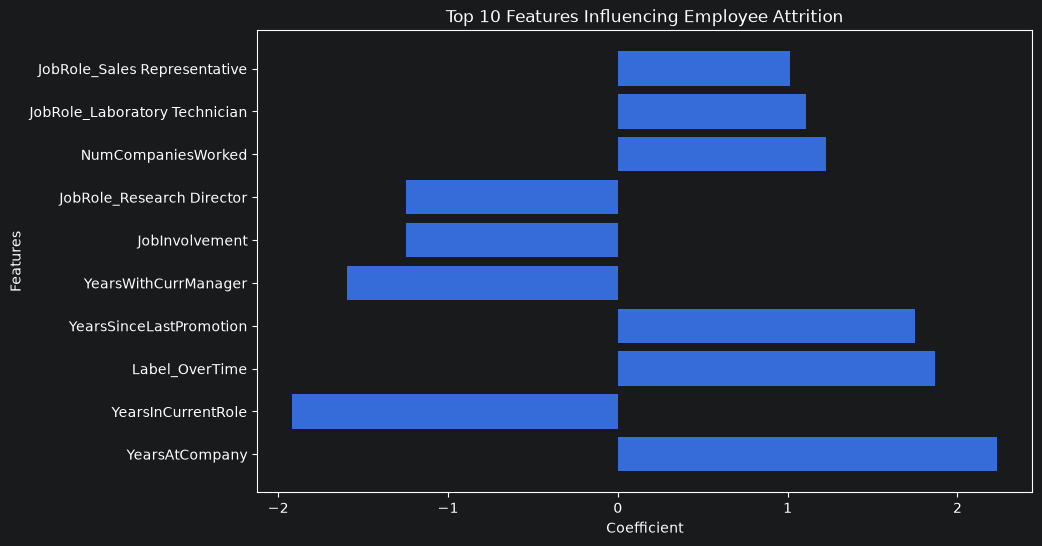

In [25]:
import matplotlib.pyplot as plt
top_features = table.head(10)
plt.figure(figsize=(10, 6))

plt.barh(top_features["Features"], top_features["Coefficient"])

plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.title("Top 10 Features Influencing Employee Attrition")

plt.show()

## Final Project Conclusion

The Balanced Logistic Regression model was selected as the final model because it achieved a higher recall for employee attrition compared to the other evaluated models.

Final Model Performance:
- Accuracy: 74.83%
- Precision: 28.40%
- Recall: 58.97%
- F1 Score: 38.33%

Recall was given more importance because, in employee attrition prediction, identifying employees who are actually going to leave is important. The balanced class weight helped the model identify more employees from the minority Attrition = Yes class.

The coefficient analysis also showed that features such as YearsAtCompany, YearsInCurrentRole, OverTime, YearsSinceLastPromotion, and YearsWithCurrManager had strong influence on the model's predictions.

This project helped me understand the complete machine learning workflow, including data preprocessing, encoding, feature scaling, model training, model evaluation, hyperparameter tuning, handling class imbalance, model selection, and model interpretation.